<center><h1>CMSE 202: Group 4 Final Project (Infrastructure & Urban Planning 2)</h1></center>

# Research Question: 
## How do rider behavior patterns across time, location, and trip characteristics- shape taxi demand, trip duration, fares, and tipping outcomes in New York City?

### This question will be investigated via the following five sub-topics:
1. Origin–destination network graphing/modeling
2. Time-of-year / time-of-day demand analysis
3. Tip likelihood logistic regression
4. Fare prediction regression
5. Trip duration modeling

In [1]:
# Import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import networkx as nx
import folium
import sklearn

In [2]:
# Read in and display first few rows of taxi traffic data set
df = pd.read_csv('taxi.csv', engine='python', on_bad_lines='skip')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount
0,2,01/01/2023 12:00:00 AM,01/01/2023 12:08:00 AM,NaN,1.53,42,41,0,12.98,0.00,14.48
1,2,01/01/2023 12:00:05 AM,01/01/2023 12:26:27 AM,1.0,1.32,249,186,2,21.9,0.00,26.9
2,2,01/01/2023 12:00:06 AM,01/01/2023 12:05:44 AM,1.0,1.7,125,68,2,9.3,0.00,14.3
3,2,01/01/2023 12:00:08 AM,01/01/2023 12:11:24 AM,1.0,3.1,42,244,2,16.3,0.00,18.8
4,2,01/01/2023 12:00:09 AM,01/01/2023 12:15:10 AM,1.0,3.8,79,231,1,19.8,7.44,32.24


### Accessed and used code from ChatGPT (chatgpt.com) on 11/12/25
##### Prompt 1: "Can you give me a way to transform a column like this into more usable data such as month, day, year, hour, minute? 01/08/2023 09:22:43 AM?"
##### Prompt 2: "How do I moved these new columns to a specific spot earlier in the data frame?"

In [3]:
# Change date-time pickup and drop-off columns to a new, usable form
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='%m/%d/%Y %I:%M:%S %p')
df['dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='%m/%d/%Y %I:%M:%S %p')

# Create new columns for pickup and drop-off times
df['month'] = df['pickup_datetime'].dt.month
df['pickup day'] = df['pickup_datetime'].dt.day
df['pickup hour'] = df['pickup_datetime'].dt.hour
df['pickup minute'] = df['pickup_datetime'].dt.minute
df['trip_duration_minutes'] = round((df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60, 2)

# Insert new columns into specified locations within the data set 
cols = list(df.columns)
insert_pos = cols.index('tpep_pickup_datetime') + 1
for col in ['month', 'pickup day', 'pickup hour', 'pickup minute', 'trip_duration_minutes']:
    cols.insert(insert_pos, cols.pop(cols.index(col)))
    insert_pos += 1

# Drop unnecessary columns and shorten data set due to its many rows
df = df[cols]
df.drop(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'dropoff_datetime'], axis=1, inplace=True)
df = df[(df['pickup day'] <= 14) & (df['month'] == 1)]

In [4]:
# Display data
display(df.head())
display(df.tail())

,month,pickup day,pickup hour,pickup minute,trip_duration_minutes,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,pickup_datetime
0,1,1,0,0,8.00,NaN,1.53,42,41,0,12.98,0.00,14.48,2023-01-01 00:00:00
1,1,1,0,0,26.37,1.0,1.32,249,186,2,21.9,0.00,26.9,2023-01-01 00:00:05
2,1,1,0,0,5.63,1.0,1.7,125,68,2,9.3,0.00,14.3,2023-01-01 00:00:06
3,1,1,0,0,11.27,1.0,3.1,42,244,2,16.3,0.00,18.8,2023-01-01 00:00:08
4,1,1,0,0,15.02,1.0,3.8,79,231,1,19.8,7.44,32.24,2023-01-01 00:00:09


,month,pickup day,pickup hour,pickup minute,trip_duration_minutes,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,pickup_datetime
1343542,1,14,23,59,24.53,3.0,5.2,234,87,2,26.1,0.00,31.1,2023-01-14 23:59:58
1343543,1,14,23,59,4.77,0.0,0.7,263,239,1,5.8,1.00,11.8,2023-01-14 23:59:59
1343544,1,14,23,59,4.55,1.0,1.1,236,75,1,7.2,2.40,14.6,2023-01-14 23:59:59
1343545,1,14,23,59,13.43,1.0,1.92,234,79,1,14.2,2.00,21.2,2023-01-14 23:59:59
1343546,1,14,23,59,14.55,NaN,4.56,90,151,0,25.14,5.83,34.97,2023-01-14 23:59:59


# 1. Investigating New York Taxi Traffic via Network Graphing/Modeling

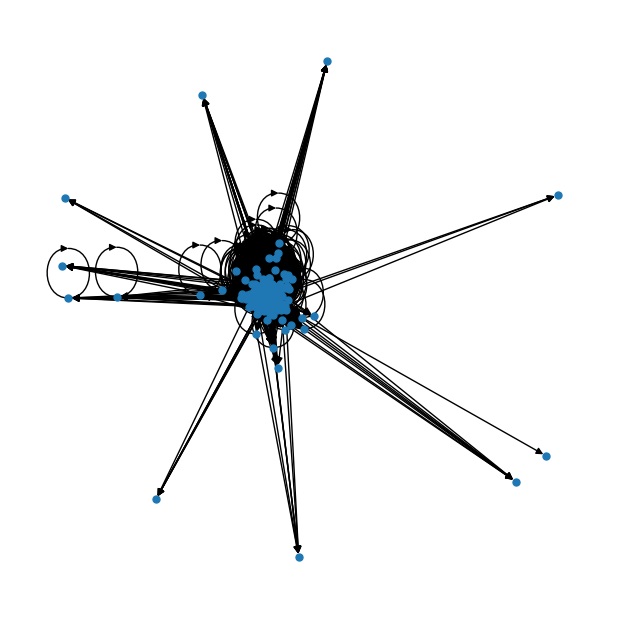

In [5]:
# Initialize an empty directed graph
G = nx.DiGraph()

# Add an edge for each trip from its pickup location to its drop-off location
for i in range(len(df['PULocationID'])):
    G.add_edge(df['PULocationID'][i], df['DOLocationID'][i])

# Set figure size
plt.figure(figsize=(6, 6))

# Determine node positions with a spring layout and draw the graph with small nodes
pos = nx.spring_layout(G, seed=67)
nx.draw(G, pos, node_size=25)

# Display figure
plt.show()

In [6]:
# Group trips by their pickup and drop-off locations and record number of occurrences for each combination
trip_counts = df.groupby(['PULocationID', 'DOLocationID']).size()

# Sort aggregated data in descending order and reset index for easier access in the future
popular_routes = trip_counts.sort_values(ascending=False).reset_index(name='count')

# Display the top 20 most popular routes and their count
display(popular_routes.head(20))

,PULocationID,DOLocationID,count
0,237,236,9584
1,236,237,8166
2,264,264,6628
3,236,236,6520
4,237,237,5923
5,237,161,4033
6,161,237,3882
7,161,236,3731
8,239,238,3611
9,141,236,3586


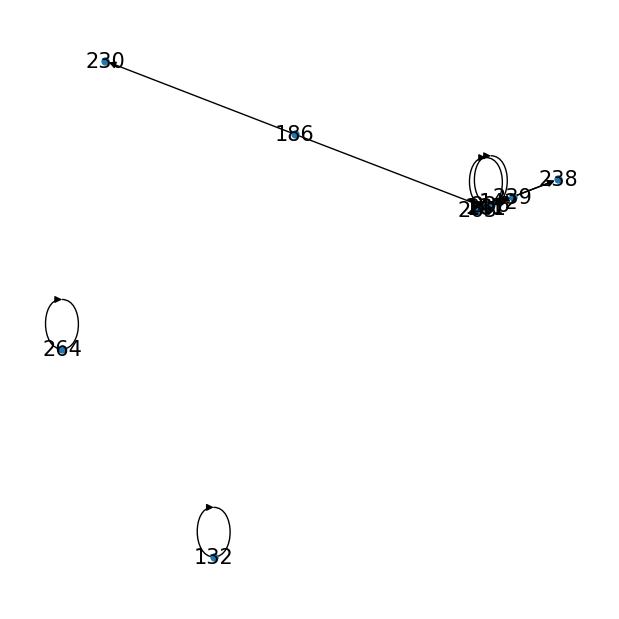

In [7]:
# Initialize a new directed graph
G_popular = nx.DiGraph()

# Add edge between 20 most popular routes
for i in range(0,20):
    G_popular.add_edge(popular_routes['PULocationID'][i], popular_routes['DOLocationID'][i], weight = popular_routes['count'][i])

plt.figure(figsize=(6, 6))

# Determine node positions with a spring layout
pos = nx.spring_layout(G_popular, seed=67)

# Draw the graph using small nodes, spring layout locations, and node ID labels
nx.draw(G_popular, pos, node_size=25, with_labels=True, font_size=15)

plt.show()

In [8]:
# Read in and display new data set 
zones = pd.read_csv("taxi_zones.csv")
display(zones.head())
display(zones.tail())

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


,LocationID,Borough,Zone,service_zone
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN
264,265,NaN,Outside of NYC,NaN


### Accessed and used code from ChatGPT (chatgpt.com) on 11/17/25
#### Prompt 1: "How do I turn my zone_dict into a legend for network graph?"

,PULocationID,DOLocationID,count
0,237,236,9584
1,236,237,8166
2,236,236,6520
3,237,237,5923
4,237,161,4033
5,161,237,3882
6,161,236,3731
7,239,238,3611
8,141,236,3586
9,142,239,3565


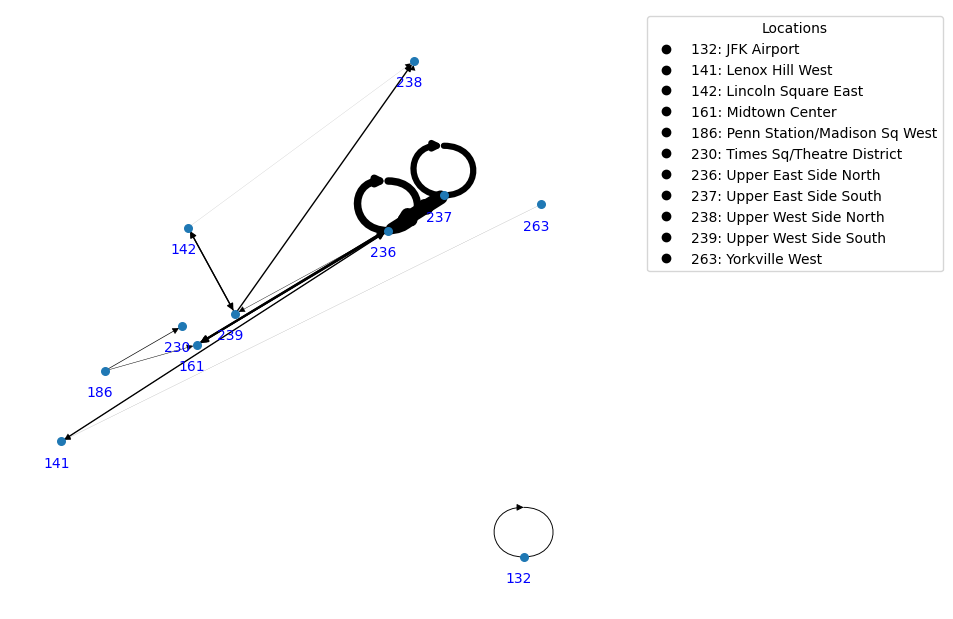

In [9]:
# Initialize an empty dictionary 
zone_dict = {}

# Drop routes connection to Location ID of 264 and 265 as these locations are either unknown, or outside of NYC
popular_routes_cleaned = popular_routes[(popular_routes['PULocationID'] != 264) & (popular_routes['PULocationID'] != 265)]

# Concatenate pickup and drop-off ID lists
# Use .unique to return an array containing each ID present in the top 20 popular routes
popular_IDs_cleaned = pd.concat([popular_routes_cleaned['PULocationID'].head(20), popular_routes_cleaned['DOLocationID'].head(20)]).unique()

# Reset index for easier access in the future
popular_routes_cleaned = popular_routes_cleaned.reset_index(drop=True)

# Add each Location ID and its corresponding real-world zone name to dictionary
for i in range(len(zones['LocationID'])):
    if zones['LocationID'][i] in popular_IDs_cleaned:
        key = zones['LocationID'][i]
        value = zones['Zone'][i]
        zone_dict[key] = value

# Create a dictionary containing actual geographical coordinates of each zone/ID for graphing (longitude & latitude)
pos = {
    132: (-73.9500,40.7200), #This is JFK Airport. Coordinates are adjusted for graph cohesion (don't match real-world location)
    141: (-73.9981,40.7390),
    142: (-73.9849,40.7742),
    161: (-73.9840,40.7549),
    186: (-73.9936,40.7506),
    230: (-73.9855,40.7580),
    236: (-73.9641,40.7737),
    237: (-73.9583,40.7795),
    238: (-73.9614,40.8016),
    239: (-73.9800,40.7600),
    263: (-73.9482,40.7780)}

# Initialize a new directed graph
G_popular = nx.DiGraph()

# Add edge between 20 most popular routes weighted by the number of occurrences
for i in range(0,20):
    G_popular.add_edge(popular_routes_cleaned['PULocationID'][i], popular_routes_cleaned['DOLocationID'][i], weight = popular_routes_cleaned['count'][i])

# Extract the weight values from directed graph
weights = np.array(list(nx.get_edge_attributes(G_popular, 'weight').values()))

# Normalize the weights in order to create a visible graph
weights_norm = (weights - weights.min()) / (weights.max() - weights.min())

# Scale the weights in order to see a larger visual differences between routes
weights_norm = weights_norm * 10

# Initialize a dictionary to store label positions
label_pos = {}

# Access location IDs and positions from pos dictionary
# Add each ID to new dictionary in addition to slightly adjusted label locations
for key, value in pos.items():
    label_pos[key] = (value[0] -0.0005, value[1] - 0.0035)
    
plt.figure(figsize=(6, 6))

# Draw the graph using small nodes, geographical coordinates, weights, and labels
nx.draw(G_popular, pos, node_size=30, width = weights_norm, with_labels=False, font_size=15)

# Draw all of the corresponding node labels using the label_pos dictionary
nx.draw_networkx_labels(G_popular, label_pos, font_size=10, font_color='blue')

# Initialize empty labels list
legend_handles = []

# Add location IDs and their corresponding zone name
for node_id, name in zone_dict.items():
    label = f"{node_id}: {name}"
    
    # Create an invisible line plot for the legend entry
    line, = plt.plot([], [], marker="o", color="black", linestyle='None', label=label)
    legend_handles.append(line)

# Display the legend
plt.legend(handles=legend_handles, title="Locations", bbox_to_anchor=(1.05, 1), loc='upper left')

display(popular_routes_cleaned.head(20))
plt.show()


### Accessed and used code from HiTA (hita.ai) on 11/20/25
#### Prompt 1: "Similar to how I created edges in my NetworkX graph, how do I created edges between nodes in my folium graph?"

In [10]:
# Re-establish geographical coordinate dictionary with every location having proper coordinates
pos = {
    132: (-73.7797,40.6446),
    141: (-73.9981,40.7390),
    142: (-73.9849,40.7742),
    161: (-73.9840,40.7549),
    186: (-73.9936,40.7506),
    230: (-73.9855,40.7580),
    236: (-73.9641,40.7737),
    237: (-73.9583,40.7795),
    238: (-73.9614,40.8016),
    239: (-73.9800,40.7600),
    263: (-73.9482,40.7780)}

# Initialize a folium map with included starting location
map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add nodes to the map using coordinates in pos dictionary, and labels in zone_dict dictionary
for node_id, coords in pos.items():
    lat, lon = coords[1], coords[0] 
    zone_name = zone_dict.get(node_id, "Unknown")
    folium.Marker(location=[lat, lon], popup=f"{node_id}: {zone_name}").add_to(map_nyc)

# Loop over starting and ending nodes in previous graph
for start_node, end_node in G_popular.edges():

    # Save geographical coordinates of each node in a new variable
    start_coords = pos.get(start_node)
    end_coords = pos.get(end_node)

    # Unpack each the coordinates of each node (unpack latitude and longitude)
    start_lat, start_lon = start_coords[1], start_coords[0]
    end_lat, end_lon = end_coords[1], end_coords[0]

    # Create a list of the start and end coordinates to define the path
    locations = [[start_lat, start_lon], [end_lat, end_lon]]

    # Add segment/edge connecting starting and ending locations
    folium.PolyLine(locations=locations, color='blue', weight=3).add_to(map_nyc)

map_nyc

# 2. Time-of-year / time-of-day demand analysis

### Hourly Demand By Hour Of Day

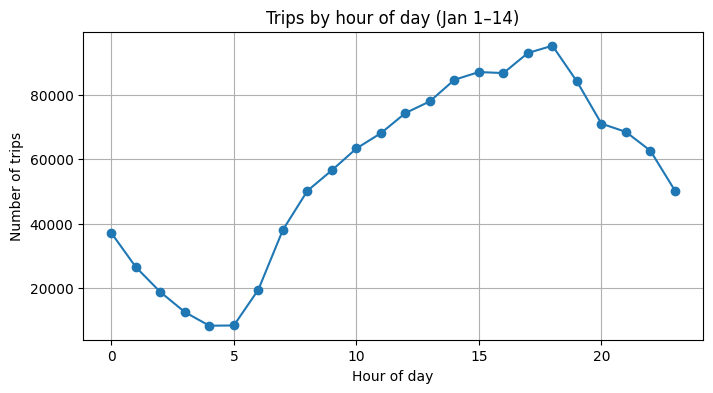

In [11]:
df['day_of_week'] = df['pickup_datetime'].dt.day_name()
df['date'] = df['pickup_datetime'].dt.date
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Overall hourly demand 
hourly_counts = df.groupby('pickup hour').size()
plt.figure(figsize=(8, 4))
hourly_counts.plot(kind='line', marker='o')
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.title('Trips by hour of day (Jan 1–14)')
plt.grid(True)
plt.show()

The hourly demand plot shows a clear and intuitive daily pattern in how people use taxis. Very early morning hours (around 3-6 AM) show the lowest number of trips, likely because most people are home and few activities occur at night. Demand begins to rise sharply around 7 AM, which matches the start of morning commuting times. After a small plateau late in the morning, trip counts increase again and reach their peak between 4 PM and 7 PM. This is the traditional evening rush period, when people are leaving work or transitioning between daily activities. After 8 PM, the number of trips gradually decreases throughout the night. Overall, this plot shows that taxi demand strongly follows human work schedules and daily routines, with clear peaks during commuting hours and low activity during late-night periods.

### Weekday vs Weekend Pattern

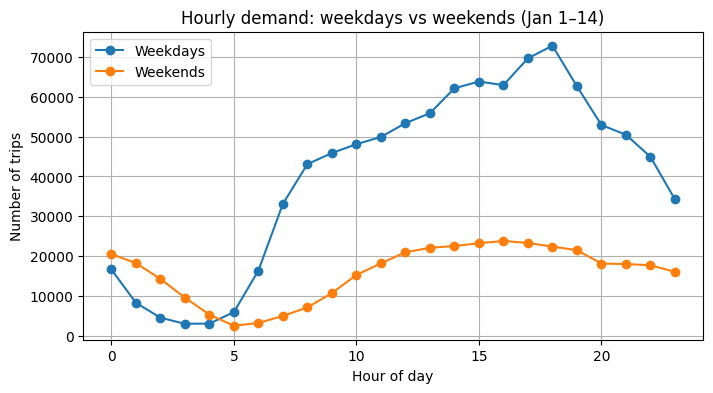

In [12]:
# Weekday vs weekend pattern
hourly_weekday = df[~df['is_weekend']].groupby('pickup hour').size()
hourly_weekend = df[df['is_weekend']].groupby('pickup hour').size()

plt.figure(figsize=(8, 4))
plt.plot(hourly_weekday.index, hourly_weekday.values, marker='o', label='Weekdays')
plt.plot(hourly_weekend.index, hourly_weekend.values, marker='o', label='Weekends')
plt.xlabel('Hour of day')
plt.ylabel('Number of trips')
plt.title('Hourly demand: weekdays vs weekends (Jan 1–14)')
plt.legend()
plt.grid(True)
plt.show()

Comparing weekdays and weekends reveals important differences in how people travel. Weekdays have a strong and predictable structure: demand is very low before sunrise, begins rising sharply around 6-7 AM, and forms a major peak in the afternoon and early evening (about 4-7 PM). This reflects work and school commuting patterns, where most trips occur at the beginning and end of the day. Weekends look completely different. The morning rise is much slower, showing people wake later and have fewer early commitments. Weekend trips stay at lower levels overall, but they maintain steady demand throughout mid-day and into the evening, suggesting more leisure activities rather than commuting. Additionally, the weekend curve is much flatter, with no strong morning or afternoon peak. This comparison shows how weekday travel is structured and predictable, while weekend travel is more relaxed and spread out, reflecting different lifestyles and travel motives.

### Hour and Day-Of-Week Pattern

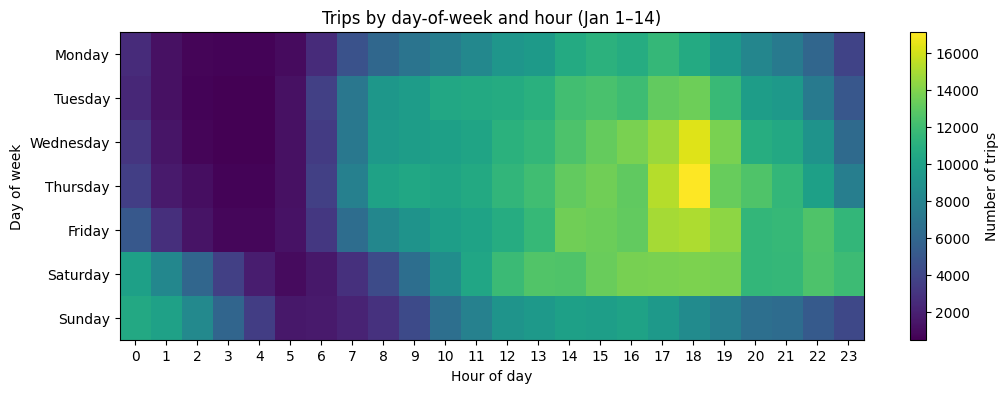

In [13]:
# Hour and day-of-week 
pivot = df.groupby(['day_of_week', 'pickup hour']).size().unstack(fill_value=0)

# Put days in order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(day_order)

plt.figure(figsize=(12, 4))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Number of trips')
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)
plt.xlabel('Hour of day')
plt.ylabel('Day of week')
plt.title('Trips by day-of-week and hour (Jan 1–14)')
plt.show()


The heatmap reveals strong differences in taxi demand across both hours of the day and days of the week. Weekdays (Monday-Friday) show a clear commuting pattern: demand is very low during the early morning hours (1-5 AM), increases rapidly after 6 AM, and remains high through the afternoon. The brightest region appears around 5-7 PM on Wednesday and Thursday, representing the peak evening rush hour when people travel home from work. Friday also shows elevated demand in the late afternoon, reflecting increased evening social activity. In contrast, weekends follow a different pattern. Both Saturday and Sunday start with higher early-morning demand compared to weekdays, likely due to late-night leisure travel. Weekend demand rises gradually through midday and stays consistently high from 10 AM to 8 PM, without the sharp morning or evening spikes seen on weekdays. This indicates that weekend taxi usage is driven more by flexible leisure activities rather than structured commuting patterns.

### Daily Demand (Trip Counts)

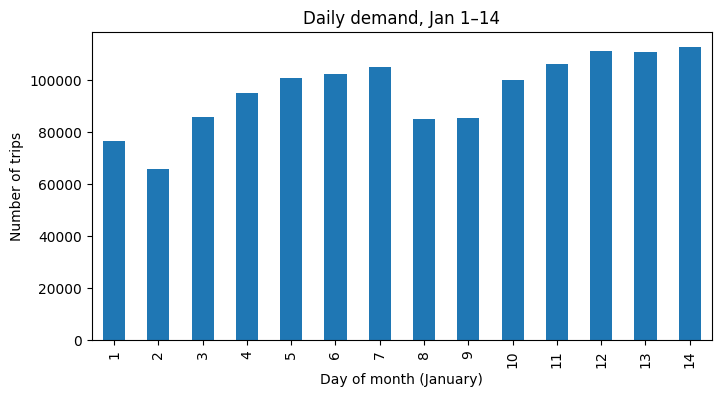

In [14]:
# Daily totals over Jan 1-14 
daily_counts = df.groupby('pickup day').size()
plt.figure(figsize=(8, 4))
daily_counts.plot(kind='bar')
plt.xlabel('Day of month (January)')
plt.ylabel('Number of trips')
plt.title('Daily demand, Jan 1–14')
plt.savefig("daily_totals.png", dpi=300, bbox_inches='tight')
plt.show()

The bar chart illustrates the total number of taxi trips taken on each day from January 1 to January 14. A clear upward trend is visible across the two-week period: earlier days, such as January 1-3, show noticeably lower trip volumes, while demand increases steadily toward the middle and end of the period. The highest trip counts occur on January 12-14, suggesting increased activity as the month progresses. This pattern may reflect people returning to normal routines after holidays, improving weather, or more weekend and mid-month travel. Overall, the chart reveals consistent growth in daily taxi demand.

## 5. SKLearn Regression Line / Equation

### Further cleaning of data and initialization of name lists

This code copies the dataframe, converts trip_distance to numeric, removes rows with missing or invalid values, filters trips to reasonable durations and distances, and then defines X as the predictor variables and y as the target trip duration minutes.
I chose to filter the data to prevent incorrect or extreme entries from distorting the model.

In [15]:
df_model = df.copy()

df_model["trip_distance"] = pd.to_numeric(df_model["trip_distance"], errors="coerce")

df_model = df_model.dropna(subset=["trip_duration_minutes","trip_distance","passenger_count"])
df_model = df_model[df_model["trip_duration_minutes"] > 0]
df_model = df_model[df_model["trip_duration_minutes"] <= 120]
df_model = df_model[df_model["trip_distance"] > 0]

X = df_model[["trip_distance","pickup hour","pickup day","pickup minute","passenger_count"]]
y = df_model["trip_duration_minutes"]

### SKLearn function and supporting value calculations

This code splits the cleaned data into training and test sets, fits a linear regression model on the training data, and calculates the test set R2 score along with the model's intercept and coefficients.

• The R2 score shows how much of the variation in trip duration is explained by the model.  
• The equation learned by the regression model is: predicted_trip_duration_minutes = 6.252 + 1.953 * trip_distance + 0.022 * pickup hour + 0.115 * pickup day - 0.002 * pickup minute + 0.108 * passenger_count  
• The intercept represents the baseline predicted duration when all predictor values are zero.  
• Each coefficient number represents how many minutes are added to the predicted duration for a one unit increase in that variable while holding the others constant.

In [16]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=0)

model = sklearn.linear_model.LinearRegression()
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)

print("R^2:", r2)
print("Intercept (minutes):", model.intercept_)
print("Coefficients (minutes per unit):")
print(pd.Series(model.coef_, index=X.columns))

R^2: 0.6205825204940008
Intercept (minutes): 6.2519976422479004
Coefficients (minutes per unit):
trip_distance      1.953015
pickup hour        0.022181
pickup day         0.114734
pickup minute     -0.002409
passenger_count    0.107822
dtype: float64


### Further filtering of outliers and initialization of useful variables

• df_filter = df_model[df_model["trip_distance"] <= 300] keeps only trips with a distance of 300 or less to remove outliers and not affect the graphs.  
• features = [...] is the list of model input columns you will graph.  
• titles is a simple dictionary that gives cleaner names for the plot labels.  
• coefs = pd.Series(model.coef_, index=features) stores each regression coefficient and labels it with the correct feature name.  
• meds = df_filter[features].median() gets the median value of each feature so the other variables can be held constant when graphing.  
• inter = model.intercept_ saves the intercept from the regression model for use in the prediction equations.

In [17]:
df_filter = df_model[df_model["trip_distance"] <= 300]

features = ["trip_distance","pickup hour","pickup day","pickup minute","passenger_count"]
titles = {"trip_distance":"Trip Distance (Miles)", "pickup hour":"Pickup Hour", "pickup day":"Pickup Day",
          "pickup minute":"Pickup Minute", "passenger_count":"Passenger Count"}

coefs = pd.Series(model.coef_, index=features)
meds = df_filter[features].median()
inter = model.intercept_

### Visualizing trends in Regression Lines vs. Original Data

This section of code generates one regression plot for each predictor variable. The loop begins by cycling through every variable included in the model. For whichever variable is being plotted, the expression used to compute const_part determines the constant portion of the regression equation by inserting the median values of all other predictors. This approach guarantees that the resulting graph changes only with respect to the selected feature. The slope of the line is taken directly from that feature’s regression coefficient.

The commands that assign x_data and y_data extract the observed values for the chosen feature along with the corresponding trip durations from the filtered dataset. A continuous set of x-values is created using linspace, and the predicted y-values are then computed using the regression formula.

A new plot window is opened, and the data is shown as a scatter plot with the model’s predicted line drawn in red. The axis labels and title use the descriptive names stored in the titles dictionary. Finally, tight_layout adjusts spacing for clarity, and show displays the finished plot before the loop moves on to the next variable.

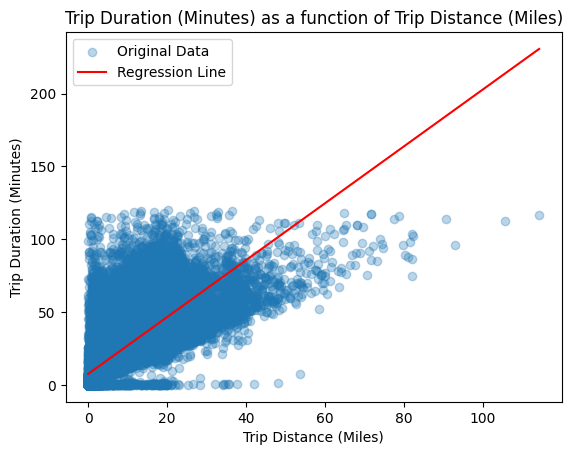

/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


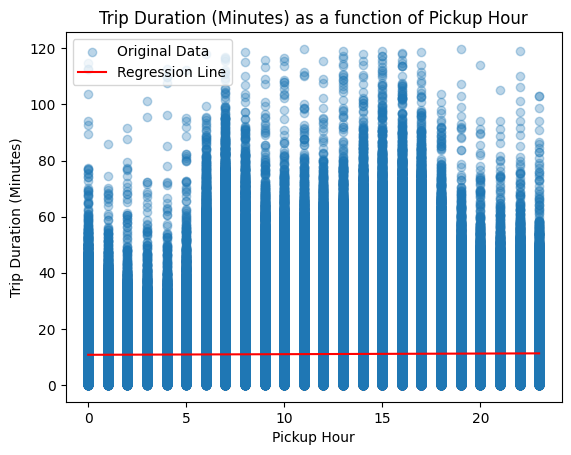

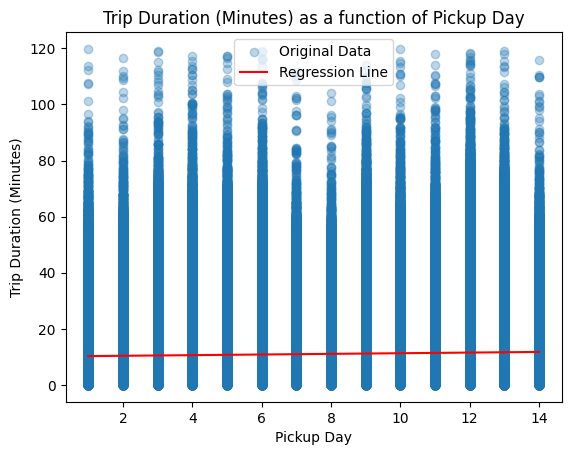

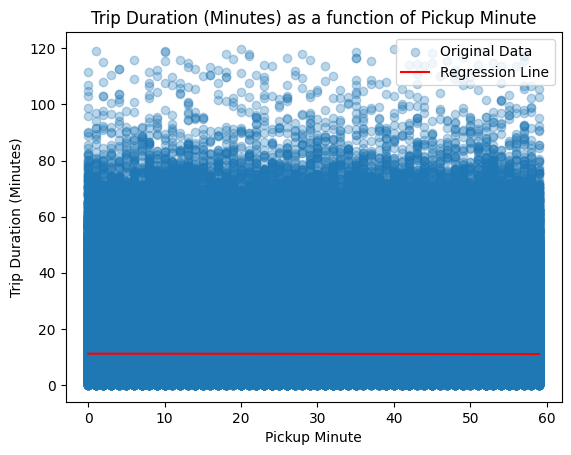

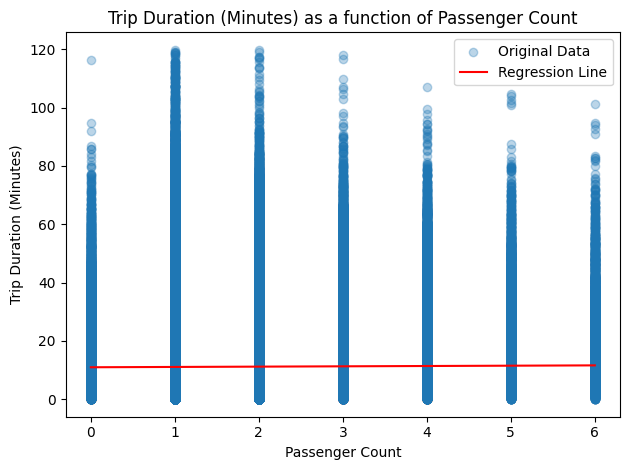

In [18]:
for feat in features:
    const_part = inter + (coefs.drop(feat) * meds.drop(feat)).sum()
    slope = coefs[feat]

    x_data = df_filter[feat]
    y_data = df_filter["trip_duration_minutes"]

    x_line = np.linspace(x_data.min(), x_data.max(), 200)
    y_line = const_part + slope * x_line

    plt.figure()
    plt.scatter(x_data, y_data, alpha=0.3, label="Original Data")
    plt.plot(x_line, y_line, color="red", label="Regression Line")
    plt.xlabel(titles[feat])
    plt.ylabel("Trip Duration (Minutes)")
    plt.title(f"Trip Duration (Minutes) as a function of {titles[feat]}")
    plt.legend()

plt.tight_layout()
plt.show()